In [2]:
import time
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

from aeon.classification.interval_based import RSTSF
from tscglue.interval_models import RSTSFRandom, RSTSFUnsupervised, RSTSFUnsupervisedRaw
from tscglue import data_loader

import os
import random

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from aeon.classification import BaseClassifier
from aeon.transformations.collection.convolution_based._hydra import HydraTransformer
from aeon.datasets.tsc_datasets import univariate

from tscglue import utils
import polars as pl
from pathlib import Path
from aeon.visualisation import plot_critical_difference
from sklearn.linear_model import RidgeClassifierCV
from aeon.transformations.collection import Normalizer
from aeon.datasets.tsc_datasets import univariate
from aeon.transformations.collection.convolution_based import MultiRocket
from aeon.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, QuantileTransformer, RobustScaler
from aeon.datasets import load_arrow_head
from tscglue.models import NoScaler, SparseScaler
from aeon.transformations.collection import Tabularizer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from aeon.utils.validation import check_n_jobs
from itertools import product
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier
from aeon.classification.interval_based import QUANTClassifier


2026-04-17 07:15:39.754750: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
class LocalFileCache:
    def __init__(self, base_dir: str):
        self.base_dir = Path(base_dir)
        self.base_dir.mkdir(parents=True, exist_ok=True)

    def exists(self, filename: str) -> bool:
        return (self.base_dir / filename).exists()

    def add(self, df: pl.DataFrame, filename: str):
        df.write_parquet(self.base_dir / filename)

In [46]:


classifiers = [
    # RSTSF(n_estimators=200, n_intervals=50, random_state=42, n_jobs=-1),
    RSTSFRandom(n_estimators=200, n_intervals=600, random_state=42, n_jobs=-1),
    RSTSFUnsupervised(n_estimators=200, n_intervals=50, random_state=42, n_jobs=-1),
    # RSTSFUnsupervisedRaw(n_intervals=50, random_state=42, n_jobs=-1)
]
#ridge, rf, ef, nn
#ridge enaki parametri kot ROCKET, vec intercalov 2000,
estimators = [
    # RidgeClassifierCV(),
    # RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    # ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    # KNeighborsClassifier(n_neighbors=1), # Typical 'nn' in TSC is 1-NN
    RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
]

final_classifiers = []

for est in estimators:
    # final_classifiers.append(
    #     RSTSFRandom(n_estimators=200, n_intervals=600, random_state=42, n_jobs=-1, estimator=est)
    # )
    # final_classifiers.append(
    #     RSTSFUnsupervised(n_estimators=200, n_intervals=50, random_state=42, n_jobs=-1, estimator=est)
    # )
    final_classifiers.append(
        RSTSFRandom(n_estimators=200, n_intervals=2000, random_state=42, n_jobs=-1, estimator=est)
    )
print(univariate)
combos = list(product(
    univariate,
    final_classifiers
))

['ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ', 'ArrowHead', 'Beef', 'BeetleFly', 'BirdChicken', 'BME', 'Car', 'CBF', 'Chinatown', 'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX', 'CricketY', 'CricketZ', 'Crop', 'DiatomSizeReduction', 'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW', 'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200', 'ECG5000', 'ECGFiveDays', 'ElectricDevices', 'EOGHorizontalSignal', 'EOGVerticalSignal', 'EthanolLevel', 'FaceAll', 'FaceFour', 'FacesUCR', 'FiftyWords', 'Fish', 'FordA', 'FordB', 'FreezerRegularTrain', 'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2', 'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint', 'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung', 'Ham', 'HandOutlines', 'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate', 'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'I

In [47]:
print(len(combos))

128


In [48]:
from tqdm import tqdm

cache = LocalFileCache("RSTSF")
n = len(combos)
# seed = os.getpid()
# random.Random(seed).shuffle(combos)
for i, (dataset,classifier) in tqdm(list(enumerate(combos, 1)), total=len(combos)):
    try:
        stats = {
            "dataset": dataset,
            "model": f"{classifier}",
        }
        hash_val = pl.DataFrame([stats]).hash_rows(seed=42, seed_1=1, seed_2=2, seed_3=3).item()
        file_name = f"{hash_val}.parquet"
        if cache.exists(file_name):
            continue

        X_train, y_train, X_test, y_test = data_loader.load_fold(dataset, fold=5)
        clf = classifier
        t0 = time.perf_counter()
        clf.fit(X_train, y_train)
        fit_time = time.perf_counter() - t0

        t0 = time.perf_counter()
        acc = accuracy_score(y_test, clf.predict(X_test))
        pred_time = time.perf_counter() - t0

        stats["accuracy"] = acc
        stats["fit_s"] = round(fit_time, 1)
        stats["predict_s"] = round(pred_time, 2)
        # print(dataset, acc)
        df_stat = pl.DataFrame([stats])
        cache.add(df_stat, file_name)
    except Exception as e:
        print(f"Error processing Dataset={dataset}: {e}")

  2%|▏         | 2/128 [06:44<7:43:48, 220.86s/it]

Error processing Dataset=AllGestureWiimoteX: [Errno 2] No such file or directory: '/home/kosir/TSCGlue/tscglue/../data/AllGestureWiimoteX/AllGestureWiimoteX5_TRAIN.ts'
Error processing Dataset=AllGestureWiimoteY: [Errno 2] No such file or directory: '/home/kosir/TSCGlue/tscglue/../data/AllGestureWiimoteY/AllGestureWiimoteY5_TRAIN.ts'
Error processing Dataset=AllGestureWiimoteZ: [Errno 2] No such file or directory: '/home/kosir/TSCGlue/tscglue/../data/AllGestureWiimoteZ/AllGestureWiimoteZ5_TRAIN.ts'


 20%|█▉        | 25/128 [2:40:22<13:19:40, 465.83s/it] 

Error processing Dataset=DodgerLoopDay: [Errno 2] No such file or directory: '/home/kosir/TSCGlue/tscglue/../data/DodgerLoopDay/DodgerLoopDay5_TRAIN.ts'
Error processing Dataset=DodgerLoopGame: [Errno 2] No such file or directory: '/home/kosir/TSCGlue/tscglue/../data/DodgerLoopGame/DodgerLoopGame5_TRAIN.ts'
Error processing Dataset=DodgerLoopWeekend: [Errno 2] No such file or directory: '/home/kosir/TSCGlue/tscglue/../data/DodgerLoopWeekend/DodgerLoopWeekend5_TRAIN.ts'


 24%|██▍       | 31/128 [3:55:08<25:51:49, 959.90s/it]/home/kosir/TSCGlue/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:836: RuntimeWarning: divide by zero encountered in scalar divide
  pacf[i + 1] = 2 / d[i + 1] * v[i + 1 :].dot(u[i:-1])
/home/kosir/TSCGlue/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:836: RuntimeWarning: invalid value encountered in scalar multiply
  pacf[i + 1] = 2 / d[i + 1] * v[i + 1 :].dot(u[i:-1])
/home/kosir/TSCGlue/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:836: RuntimeWarning: divide by zero encountered in scalar divide
  pacf[i + 1] = 2 / d[i + 1] * v[i + 1 :].dot(u[i:-1])
/home/kosir/TSCGlue/.venv/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:836: RuntimeWarning: invalid value encountered in scalar multiply
  pacf[i + 1] = 2 / d[i + 1] * v[i + 1 :].dot(u[i:-1])
 42%|████▏     | 54/128 [7:03:12<5:52:57, 286.18s/it]  

...

 66%|██████▋   | 85/128 [9:13:12<3:08:34, 263.12s/it] 

Error processing Dataset=PickupGestureWiimoteZ: [Errno 2] No such file or directory: '/home/kosir/TSCGlue/tscglue/../data/PickupGestureWiimoteZ/PickupGestureWiimoteZ5_TRAIN.ts'
Error processing Dataset=PLAID: [Errno 2] No such file or directory: '/home/kosir/TSCGlue/tscglue/../data/PLAID/PLAID5_TRAIN.ts'


 84%|████████▎ | 107/128 [9:23:50<28:28, 81.37s/it]  

Error processing Dataset=ShakeGestureWiimoteZ: [Errno 2] No such file or directory: '/home/kosir/TSCGlue/tscglue/../data/ShakeGestureWiimoteZ/ShakeGestureWiimoteZ5_TRAIN.ts'


100%|██████████| 128/128 [11:47:50<00:00, 331.80s/it]  


/tmp/ipykernel_513437/140437188.py:27: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df_matrix = df.pivot(


(<Figure size 600x320 with 1 Axes>, <Axes: >)

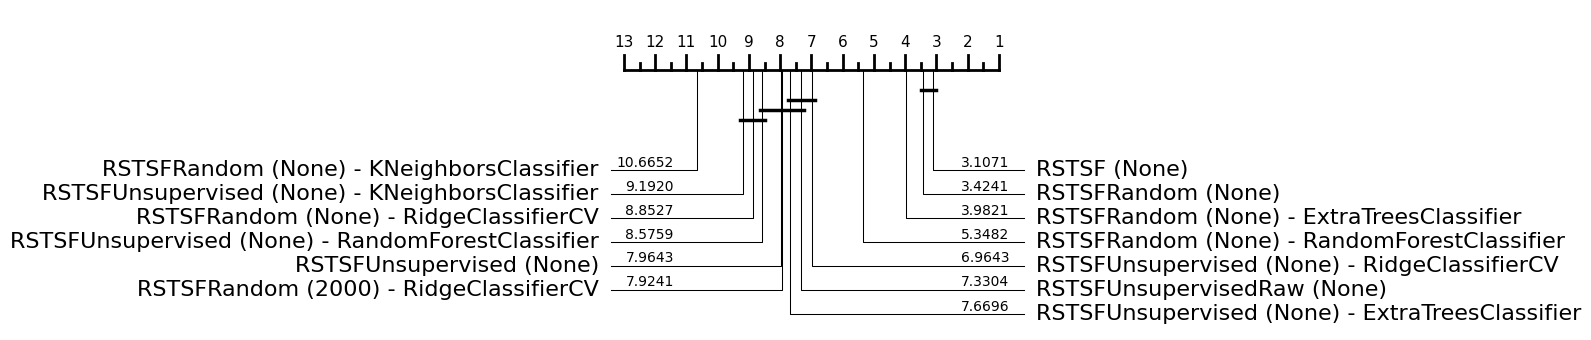

In [7]:
import polars as pl
import re

df = pl.read_parquet('RSTSF/*.parquet')

# 1. Clean the 'model' column using regex
# This extracts the Class name and the 'estimator' parameter if they exist
df = df.with_columns(
    # 1. Extract Base Name (e.g., RSTSFRandom)
    pl.col("model").str.extract(r"^([a-zA-Z0-9]+)\(", 1).alias("base_name"),
    # 2. Extract Estimator (if exists)
    pl.col("model").str.extract(r"estimator=([a-zA-Z0-9]+)", 1).alias("est_name"),
    # 3. Extract Intervals (to distinguish 600 vs 2000)
    pl.col("model").str.extract(r"n_intervals=([0-9]+)", 1).alias("intervals")
).with_columns(
    # Combine everything into a clear name
    pl.struct(["base_name", "est_name", "intervals"]).map_elements(
        lambda x: (
            f"{x['base_name']} ({x['intervals']})" +
            (f" - {x['est_name']}" if x['est_name'] else "")
        ),
        return_dtype=pl.String
    ).alias("model")
)

# 2. Proceed with Pivot and Plotting
df_matrix = df.pivot(
    index="dataset",
    columns="model",
    values="accuracy"
)

# Extract column names (excluding 'dataset')
scalers_used = df_matrix.columns[1:]
accs = df_matrix.select(scalers_used).to_numpy()

# Note: many CD plot libs expect (estimators, datasets) or vice versa
# Ensure accs is in the shape your specific plot_critical_difference expects
plot_critical_difference(accs, scalers_used)

In [6]:
import polars as pl
import re
import matplotlib.pyplot as plt
import numpy as np

df = pl.read_parquet('RSTSF/*.parquet')

# 1. FIXED REGEX:
# - base_name: Capture everything before the first '('
# - est_name: Capture the word after 'estimator=' but stop at ',' or ')'
df = df.with_columns(
    pl.col("model").str.extract(r"^([a-zA-Z0-9]+)\(", 1).alias("base_name"),
    pl.col("model").str.extract(r"estimator=([a-zA-Z0-9]+)", 1).alias("est_name")
).with_columns(
    pl.struct(["base_name", "est_name"]).map_elements(
        lambda x: f"{x['base_name']} - {x['est_name']}" if x['est_name'] else x['base_name'],
        return_dtype=pl.String
    ).alias("model")
)

# 2. Pivot
df_matrix = df.pivot(
    index="dataset",
    columns="model",
    values="accuracy"
)

# 3. SELECT THE CORRECT NAMES FROM YOUR ERROR LOG
# According to your log, your columns are named like this:
model_x = "RSTSFRandom - RandomForestClassifier"
model_y = "RSTSFRandom - ExtraTreesClassifier"

# 4. Filter and Plot
df_plot = df_matrix.select(["dataset", model_x, model_y]).drop_nulls()

x = df_plot[model_x].to_numpy()
y = df_plot[model_y].to_numpy()

plt.figure(figsize=(8, 8))
plt.scatter(x, y, alpha=0.5, c='green', edgecolors='black')
plt.plot([0, 1], [0, 1], 'r--', label='Equal Accuracy')

plt.xlabel(model_x)
plt.ylabel(model_y)
plt.title("Comparison: RF vs ET on RSTSFRandom")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print the top 5 datasets where they differ most
df_diff = df_plot.with_columns(
    abs_diff=(pl.col(model_x) - pl.col(model_y)).abs()
).sort("abs_diff", descending=True)

print("Top datasets where models disagree:")
print(df_diff.head(5))

/tmp/ipykernel_513437/2285623624.py:22: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df_matrix = df.pivot(


ComputeError: aggregation 'item' expected no or a single value, got 2 values

In [28]:
import polars as pl

# 1. Define the model names from your list
model_rf = "RSTSFRandom - RandomForestClassifier"
model_et = "RSTSFRandom - ExtraTreesClassifier"

# 2. Filter, Calculate Difference, and Sort
df_rf_better = (
    df_matrix.select(["dataset", model_rf, model_et])
    .drop_nulls()
    # Calculate difference: positive means RF did better
    .with_columns(
        diff = pl.col(model_rf) - pl.col(model_et)
    )
    # Filter for only where RF outperformed ET
    .filter(pl.col("diff") > 0)
    # Sort by the biggest performance gap
    .sort("diff", descending=True)
)

print(f"Number of datasets where Random Forest outperformed Extra Trees: {len(df_rf_better)}")
print(df_rf_better.head(10))

# 3. Optional: See the datasets where they tied (often many in TSC benchmarks)
df_ties = df_matrix.filter(pl.col(model_rf) == pl.col(model_et))
print(f"Number of ties: {len(df_ties)}")

Number of datasets where Random Forest outperformed Extra Trees: 15
shape: (10, 4)
┌───────────────────┬─────────────────────────────────┬─────────────────────────────────┬──────────┐
│ dataset           ┆ RSTSFRandom - RandomForestClas… ┆ RSTSFRandom - ExtraTreesClassi… ┆ diff     │
│ ---               ┆ ---                             ┆ ---                             ┆ ---      │
│ str               ┆ f64                             ┆ f64                             ┆ f64      │
╞═══════════════════╪═════════════════════════════════╪═════════════════════════════════╪══════════╡
│ Beef              ┆ 0.6                             ┆ 0.533333                        ┆ 0.066667 │
│ MoteStrain        ┆ 0.858626                        ┆ 0.813898                        ┆ 0.044728 │
│ Coffee            ┆ 1.0                             ┆ 0.964286                        ┆ 0.035714 │
│ Herring           ┆ 0.59375                         ┆ 0.5625                          ┆ 0.03125  │
│ Middle

In [40]:
def get_metadata_from_loader(datasets):
    meta_data = []
    for d in datasets:
        try:
            # We only need to load the TRAIN set to get the dimensions
            # Usually fold 0 is the fastest/safest to check
            X_train, y_train, _, _ = data_loader.load_fold(d, fold=0)

            # aeon/tsc datasets are (n_samples, n_channels, n_timepoints)
            n_samples = X_train.shape[0]
            n_timepoints = X_train.shape[2]

            meta_data.append({
                "dataset": d,
                "n_samples": n_samples,
                "n_timepoints": n_timepoints,
                "total_cells": n_samples * n_timepoints
            })
            print(f"Metadata for {d}: {n_samples}x{n_timepoints}")
        except Exception as e:
            print(f"Skipping {d}: {e}")
            continue

    return pl.DataFrame(meta_data)

# 'univariate' is your list of folder names from os.listdir('./data')
df_meta = get_metadata_from_loader(univariate)

Metadata for ACSF1: 100x1460
Metadata for Adiac: 390x176
Skipping AllGestureWiimoteX: [Errno 2] No such file or directory: '/home/kosir/TSCGlue/tscglue/../data/AllGestureWiimoteX/AllGestureWiimoteX0_TRAIN.ts'
Skipping AllGestureWiimoteY: [Errno 2] No such file or directory: '/home/kosir/TSCGlue/tscglue/../data/AllGestureWiimoteY/AllGestureWiimoteY0_TRAIN.ts'
Skipping AllGestureWiimoteZ: [Errno 2] No such file or directory: '/home/kosir/TSCGlue/tscglue/../data/AllGestureWiimoteZ/AllGestureWiimoteZ0_TRAIN.ts'
Metadata for ArrowHead: 36x251
Metadata for Beef: 30x470
Metadata for BeetleFly: 20x512
Metadata for BirdChicken: 20x512
Metadata for BME: 30x128
Metadata for Car: 60x577
Metadata for CBF: 30x128
Metadata for Chinatown: 20x24
Metadata for ChlorineConcentration: 467x166
Metadata for CinCECGTorso: 40x1639
Metadata for Coffee: 28x286
Metadata for Computers: 250x720
Metadata for CricketX: 390x300
Metadata for CricketY: 390x300
Metadata for CricketZ: 390x300
Metadata for Crop: 7200x46
Me

In [41]:
# Assuming 'df_matrix' already exists from your previous code
model_rf = "RSTSFRandom - RandomForestClassifier"
model_et = "RSTSFRandom - ExtraTreesClassifier"

# Join results with metadata
df_analysis = df_matrix.join(df_meta, on="dataset")

# Calculate win margin
df_analysis = df_analysis.with_columns(
    rf_win_margin = pl.col(model_rf) - pl.col(model_et)
).select(["dataset", "n_samples", "n_timepoints", "total_cells", "rf_win_margin"])

# See datasets where RF won, including their size
print("Datasets where Random Forest outperformed Extra Trees (by Size):")
print(df_analysis.filter(pl.col("rf_win_margin") > 0).sort("n_samples", descending=True))

Datasets where Random Forest outperformed Extra Trees (by Size):
shape: (15, 5)
┌─────────────────────────────┬───────────┬──────────────┬─────────────┬───────────────┐
│ dataset                     ┆ n_samples ┆ n_timepoints ┆ total_cells ┆ rf_win_margin │
│ ---                         ┆ ---       ┆ ---          ┆ ---         ┆ ---           │
│ str                         ┆ i64       ┆ i64          ┆ i64         ┆ f64           │
╞═════════════════════════════╪═══════════╪══════════════╪═════════════╪═══════════════╡
│ StarLightCurves             ┆ 1000      ┆ 1024         ┆ 1024000     ┆ 0.000971      │
│ Wafer                       ┆ 1000      ┆ 152          ┆ 152000      ┆ 0.000324      │
│ UWaveGestureLibraryX        ┆ 896       ┆ 315          ┆ 282240      ┆ 0.001396      │
│ MiddlePhalanxOutlineCorrect ┆ 600       ┆ 80           ┆ 48000       ┆ 0.006873      │
│ EthanolLevel                ┆ 504       ┆ 1751         ┆ 882504      ┆ 0.01          │
│ …                           

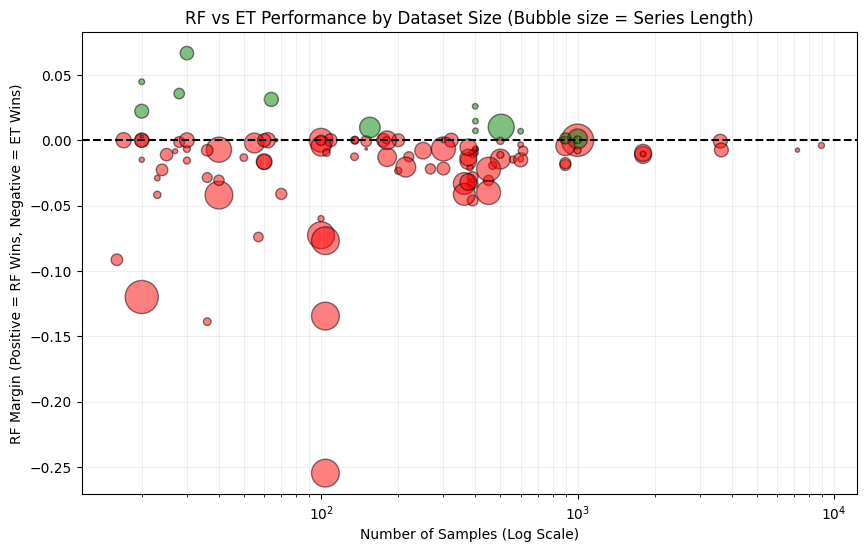

In [43]:
import matplotlib.pyplot as plt

x = df_analysis["n_samples"].to_numpy()
y = df_analysis["rf_win_margin"].to_numpy()
sizes = df_analysis["n_timepoints"].to_numpy() / 5 # Size of bubble = length of series

plt.figure(figsize=(10, 6))
# Green points = RF won, Red points = ET won
colors = ['green' if val > 0 else 'red' for val in y]

plt.scatter(x, y, s=sizes, c=colors, alpha=0.5, edgecolors='black')
plt.axhline(0, color='black', linestyle='--')

plt.xscale('log') # Use log scale because dataset sizes vary from 20 to 20,000
plt.xlabel('Number of Samples (Log Scale)')
plt.ylabel('RF Margin (Positive = RF Wins, Negative = ET Wins)')
plt.title('RF vs ET Performance by Dataset Size (Bubble size = Series Length)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()